In [20]:
import pandas as pd;
import matplotlib as plt;
import matplotlib.pyplot;
import numpy as np;
import seaborn as sns;
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
tellco_data = pd.read_excel("D:\\Projects\\Tellco_Analysis\\Data\\telco_data.xlsx")

In [3]:
tellco_data.columns

Index(['Bearer Id', 'Start', 'Start ms', 'End', 'End ms', 'Dur. (ms)', 'IMSI',
       'MSISDN/Number', 'IMEI', 'Last Location Name', 'Avg RTT DL (ms)',
       'Avg RTT UL (ms)', 'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)',
       'TCP DL Retrans. Vol (Bytes)', 'TCP UL Retrans. Vol (Bytes)',
       'DL TP < 50 Kbps (%)', '50 Kbps < DL TP < 250 Kbps (%)',
       '250 Kbps < DL TP < 1 Mbps (%)', 'DL TP > 1 Mbps (%)',
       'UL TP < 10 Kbps (%)', '10 Kbps < UL TP < 50 Kbps (%)',
       '50 Kbps < UL TP < 300 Kbps (%)', 'UL TP > 300 Kbps (%)',
       'HTTP DL (Bytes)', 'HTTP UL (Bytes)', 'Activity Duration DL (ms)',
       'Activity Duration UL (ms)', 'Dur. (ms).1', 'Handset Manufacturer',
       'Handset Type', 'Nb of sec with 125000B < Vol DL',
       'Nb of sec with 1250B < Vol UL < 6250B',
       'Nb of sec with 31250B < Vol DL < 125000B',
       'Nb of sec with 37500B < Vol UL',
       'Nb of sec with 6250B < Vol DL < 31250B',
       'Nb of sec with 6250B < Vol UL < 37500B',


In [4]:
# top 10 handsets used by customers
top_handsets = tellco_data["Handset Type"].value_counts().head(10)
print(top_handsets)

Handset Type
Huawei B528S-23A                19752
Apple iPhone 6S (A1688)          9419
Apple iPhone 6 (A1586)           9023
undefined                        8987
Apple iPhone 7 (A1778)           6326
Apple iPhone Se (A1723)          5187
Apple iPhone 8 (A1905)           4993
Apple iPhone Xr (A2105)          4568
Samsung Galaxy S8 (Sm-G950F)     4520
Apple iPhone X (A1901)           3813
Name: count, dtype: int64


In [5]:
# top 3 handset manufactures
top_manufacturer = tellco_data["Handset Manufacturer"].value_counts().head(3)
print(top_manufacturer)

Handset Manufacturer
Apple      59565
Samsung    40839
Huawei     34423
Name: count, dtype: int64


In [6]:
# Loop through each top manufacturer
for manufacturer in top_manufacturer.index:
    top_5_per_manufacturer = (
        tellco_data[tellco_data['Handset Manufacturer'] == manufacturer]['Handset Type'].value_counts().head(5)
    )
    print(f"\nTop 5 handsets for {manufacturer}:\n{top_5_per_manufacturer}")


Top 5 handsets for Apple:
Handset Type
Apple iPhone 6S (A1688)    9419
Apple iPhone 6 (A1586)     9023
Apple iPhone 7 (A1778)     6326
Apple iPhone Se (A1723)    5187
Apple iPhone 8 (A1905)     4993
Name: count, dtype: int64

Top 5 handsets for Samsung:
Handset Type
Samsung Galaxy S8 (Sm-G950F)    4520
Samsung Galaxy A5 Sm-A520F      3724
Samsung Galaxy J5 (Sm-J530)     3696
Samsung Galaxy J3 (Sm-J330)     3484
Samsung Galaxy S7 (Sm-G930X)    3199
Name: count, dtype: int64

Top 5 handsets for Huawei:
Handset Type
Huawei B528S-23A                  19752
Huawei E5180                       2079
Huawei P20 Lite Huawei Nova 3E     2021
Huawei P20                         1480
Huawei Y6 2018                      997
Name: count, dtype: int64


In [ ]:
# TASK 1.1  – aggregation (DL + UL per app)

user_behavior = tellco_data.groupby('MSISDN/Number').agg(
    num_sessions=('Bearer Id', 'count'),
    total_session_duration=('Dur. (ms)', 'sum'),
    total_download=('Total DL (Bytes)', 'sum'),
    total_upload=('Total UL (Bytes)', 'sum'),
    social_media_volume=('Social Media DL (Bytes)', 'sum'),
    social_media_ul=('Social Media UL (Bytes)', 'sum'),
    google_volume=('Google DL (Bytes)', 'sum'),
    google_ul=('Google UL (Bytes)', 'sum'),
    email_volume=('Email DL (Bytes)', 'sum'),
    email_ul=('Email UL (Bytes)', 'sum'),
    youtube_volume=('Youtube DL (Bytes)', 'sum'),
    youtube_ul=('Youtube UL (Bytes)', 'sum'),
    netflix_volume=('Netflix DL (Bytes)', 'sum'),
    netflix_ul=('Netflix UL (Bytes)', 'sum'),
    gaming_volume=('Gaming DL (Bytes)', 'sum'),
    gaming_ul=('Gaming UL (Bytes)', 'sum'),
    other_volume=('Other DL (Bytes)', 'sum'),
    other_ul=('Other UL (Bytes)', 'sum'),
).reset_index()

# Combine DL+UL into single total per app
user_behavior['social_media_volume']  = user_behavior['social_media_volume']  + user_behavior['social_media_ul']
user_behavior['google_volume']        = user_behavior['google_volume']        + user_behavior['google_ul']
user_behavior['email_volume']         = user_behavior['email_volume']         + user_behavior['email_ul']
user_behavior['youtube_volume']       = user_behavior['youtube_volume']       + user_behavior['youtube_ul']
user_behavior['netflix_volume']       = user_behavior['netflix_volume']       + user_behavior['netflix_ul']
user_behavior['gaming_volume']        = user_behavior['gaming_volume']        + user_behavior['gaming_ul']
user_behavior['other_volume']         = user_behavior['other_volume']         + user_behavior['other_ul']

# Drop the separate UL columns (no longer needed)
user_behavior.drop(columns=[c for c in user_behavior.columns if c.endswith('_ul')], inplace=True)

# Total data volume
user_behavior['total_data_volume'] = user_behavior['total_download'] + user_behavior['total_upload']

print("\n--- Aggregated user_behavior shape:", user_behavior.shape)
print(user_behavior.head())


--- Aggregated user_behavior shape: (106856, 13)
   MSISDN/Number  num_sessions  total_session_duration  total_download  \
0   3.360100e+10             1                116720.0    8.426375e+08   
1   3.360100e+10             1                181230.0    1.207552e+08   
2   3.360100e+10             1                134969.0    5.566597e+08   
3   3.360101e+10             1                 49878.0    4.019932e+08   
4   3.360101e+10             2                 37104.0    1.363130e+09   

   total_upload  social_media_volume  google_volume  email_volume  \
0    36053108.0            2232135.0      4389005.0     1331362.0   
1    36104459.0            2660565.0      5334863.0     3307781.0   
2    39306820.0            3195623.0      3443126.0     3205380.0   
3    20327526.0             280294.0      9678493.0     2284670.0   
4    94280527.0            2912542.0     18499616.0     3305469.0   

   youtube_volume  netflix_volume  gaming_volume  other_volume  \
0      21624548.0      2

In [18]:

# DEFINE KEY COLUMN GROUPS  (used throughout)
APP_COLS = [
    'social_media_volume', 'google_volume', 'email_volume',
    'youtube_volume', 'netflix_volume', 'gaming_volume', 'other_volume'
]

NUMERIC_COLS = [
    'num_sessions', 'total_session_duration', 'total_download',
    'total_upload', 'total_data_volume'
] + APP_COLS

# 1.  MISSING VALUES  –  fill with column mean
print("="*60)
print(" MISSING VALUES BEFORE CLEANING")
print("="*60)
print(user_behavior[NUMERIC_COLS].isnull().sum())

for col in NUMERIC_COLS:
    user_behavior[col].fillna(user_behavior[col].mean(), inplace=True)

print("\nMissing values after CLEANING:")
print(user_behavior[NUMERIC_COLS].isnull().sum())

 MISSING VALUES BEFORE CLEANING
num_sessions              0
total_session_duration    0
total_download            0
total_upload              0
total_data_volume         0
social_media_volume       0
google_volume             0
email_volume              0
youtube_volume            0
netflix_volume            0
gaming_volume             0
other_volume              0
dtype: int64

Missing values after CLEANING:
num_sessions              0
total_session_duration    0
total_download            0
total_upload              0
total_data_volume         0
social_media_volume       0
google_volume             0
email_volume              0
youtube_volume            0
netflix_volume            0
gaming_volume             0
other_volume              0
dtype: int64


In [21]:
# 2.  OUTLIER TREATMENT  –  IQR method, cap at 1.5*IQR
print("\n" + "="*60)
print(" OUTLIER TREATMENT  (IQR capping)")
print("="*60)

def cap_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return series.clip(lower, upper)

for col in NUMERIC_COLS:
    before = user_behavior[col].describe()
    user_behavior[col] = cap_outliers(user_behavior[col])
    after  = user_behavior[col].describe()
    print(f"\n{col}:")
    print(f"  Before – min: {before['min']:.2f}, max: {before['max']:.2f}")
    print(f"  After  – min: {after['min']:.2f},  max: {after['max']:.2f}")


 OUTLIER TREATMENT  (IQR capping)

num_sessions:
  Before – min: 1.00, max: 3.50
  After  – min: 1.00,  max: 3.50

total_session_duration:
  Before – min: 7142.00, max: 325035.50
  After  – min: 7142.00,  max: 325035.50

total_download:
  Before – min: 8827082.00, max: 1546170630.00
  After  – min: 8827082.00,  max: 1546170630.00

total_upload:
  Before – min: 2866892.00, max: 109736770.38
  After  – min: 2866892.00,  max: 109736770.38

total_data_volume:
  Before – min: 33249009.00, max: 1605763008.12
  After  – min: 33249009.00,  max: 1605763008.12

social_media_volume:
  Before – min: 1563.00, max: 6451850.25
  After  – min: 1563.00,  max: 6451850.25

google_volume:
  Before – min: 40330.00, max: 24122895.38
  After  – min: 40330.00,  max: 24122895.38

email_volume:
  Before – min: 18176.00, max: 7106272.25
  After  – min: 18176.00,  max: 7106272.25

youtube_volume:
  Before – min: 78903.00, max: 66873306.62
  After  – min: 78903.00,  max: 66873306.62

netflix_volume:
  Before – mi

Raw data shape: (150001, 55)

--- Aggregated user_behavior shape: (106856, 13)
   MSISDN/Number  num_sessions  total_session_duration  total_download  \
0   3.360100e+10             1                116720.0    8.426375e+08   
1   3.360100e+10             1                181230.0    1.207552e+08   
2   3.360100e+10             1                134969.0    5.566597e+08   
3   3.360101e+10             1                 49878.0    4.019932e+08   
4   3.360101e+10             2                 37104.0    1.363130e+09   

   total_upload  social_media_volume  google_volume  email_volume  \
0    36053108.0            2232135.0      4389005.0     1331362.0   
1    36104459.0            2660565.0      5334863.0     3307781.0   
2    39306820.0            3195623.0      3443126.0     3205380.0   
3    20327526.0             280294.0      9678493.0     2284670.0   
4    94280527.0            2912542.0     18499616.0     3305469.0   

   youtube_volume  netflix_volume  gaming_volume  other_volum

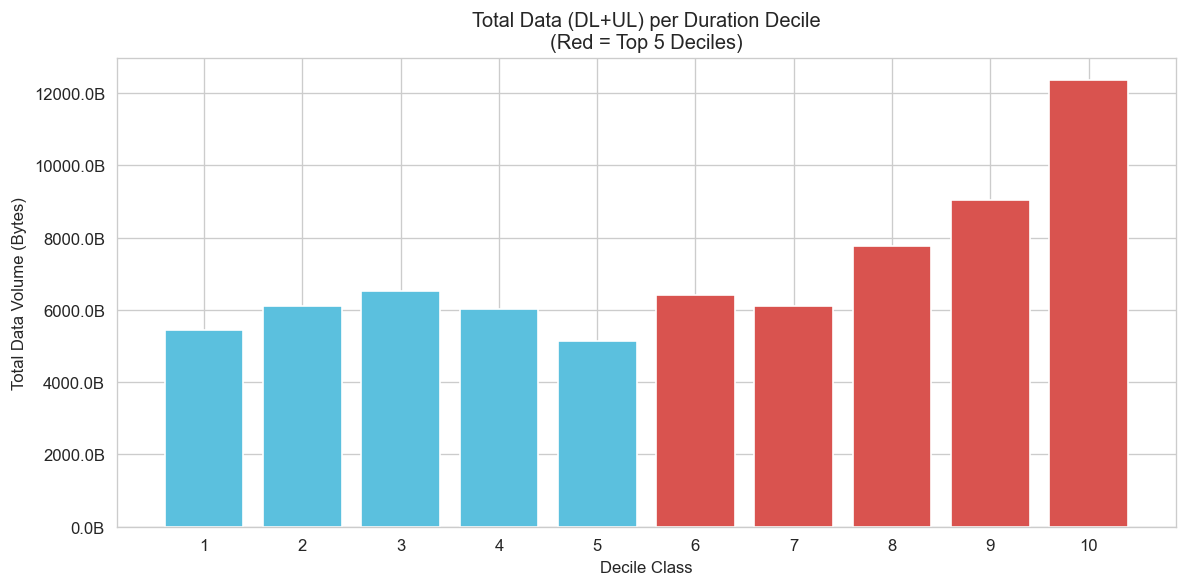


 BASIC METRICS  –  Descriptive Statistics
                           count          mean           std         min  \
num_sessions            106856.0  1.359582e+00  6.535617e-01         1.0   
total_session_duration  106856.0  1.302540e+05  8.761199e+04      7142.0   
total_download          106856.0  6.107938e+08  3.837180e+08   8827082.0   
total_upload            106856.0  5.415006e+07  2.510771e+07   2866892.0   
total_data_volume       106856.0  6.636263e+08  3.959274e+08  33249009.0   
social_media_volume     106856.0  2.463807e+06  1.606302e+06      1563.0   
google_volume           106856.0  1.040527e+07  5.907247e+06     40330.0   
email_volume            106856.0  3.012647e+06  1.752163e+06     18176.0   
youtube_volume          106856.0  3.004808e+07  1.618046e+07     78903.0   
netflix_volume          106856.0  3.004543e+07  1.625910e+07    184569.0   
gaming_volume           106856.0  5.794169e+08  3.764944e+08    306358.0   
other_volume            106856.0  5.781019e+0

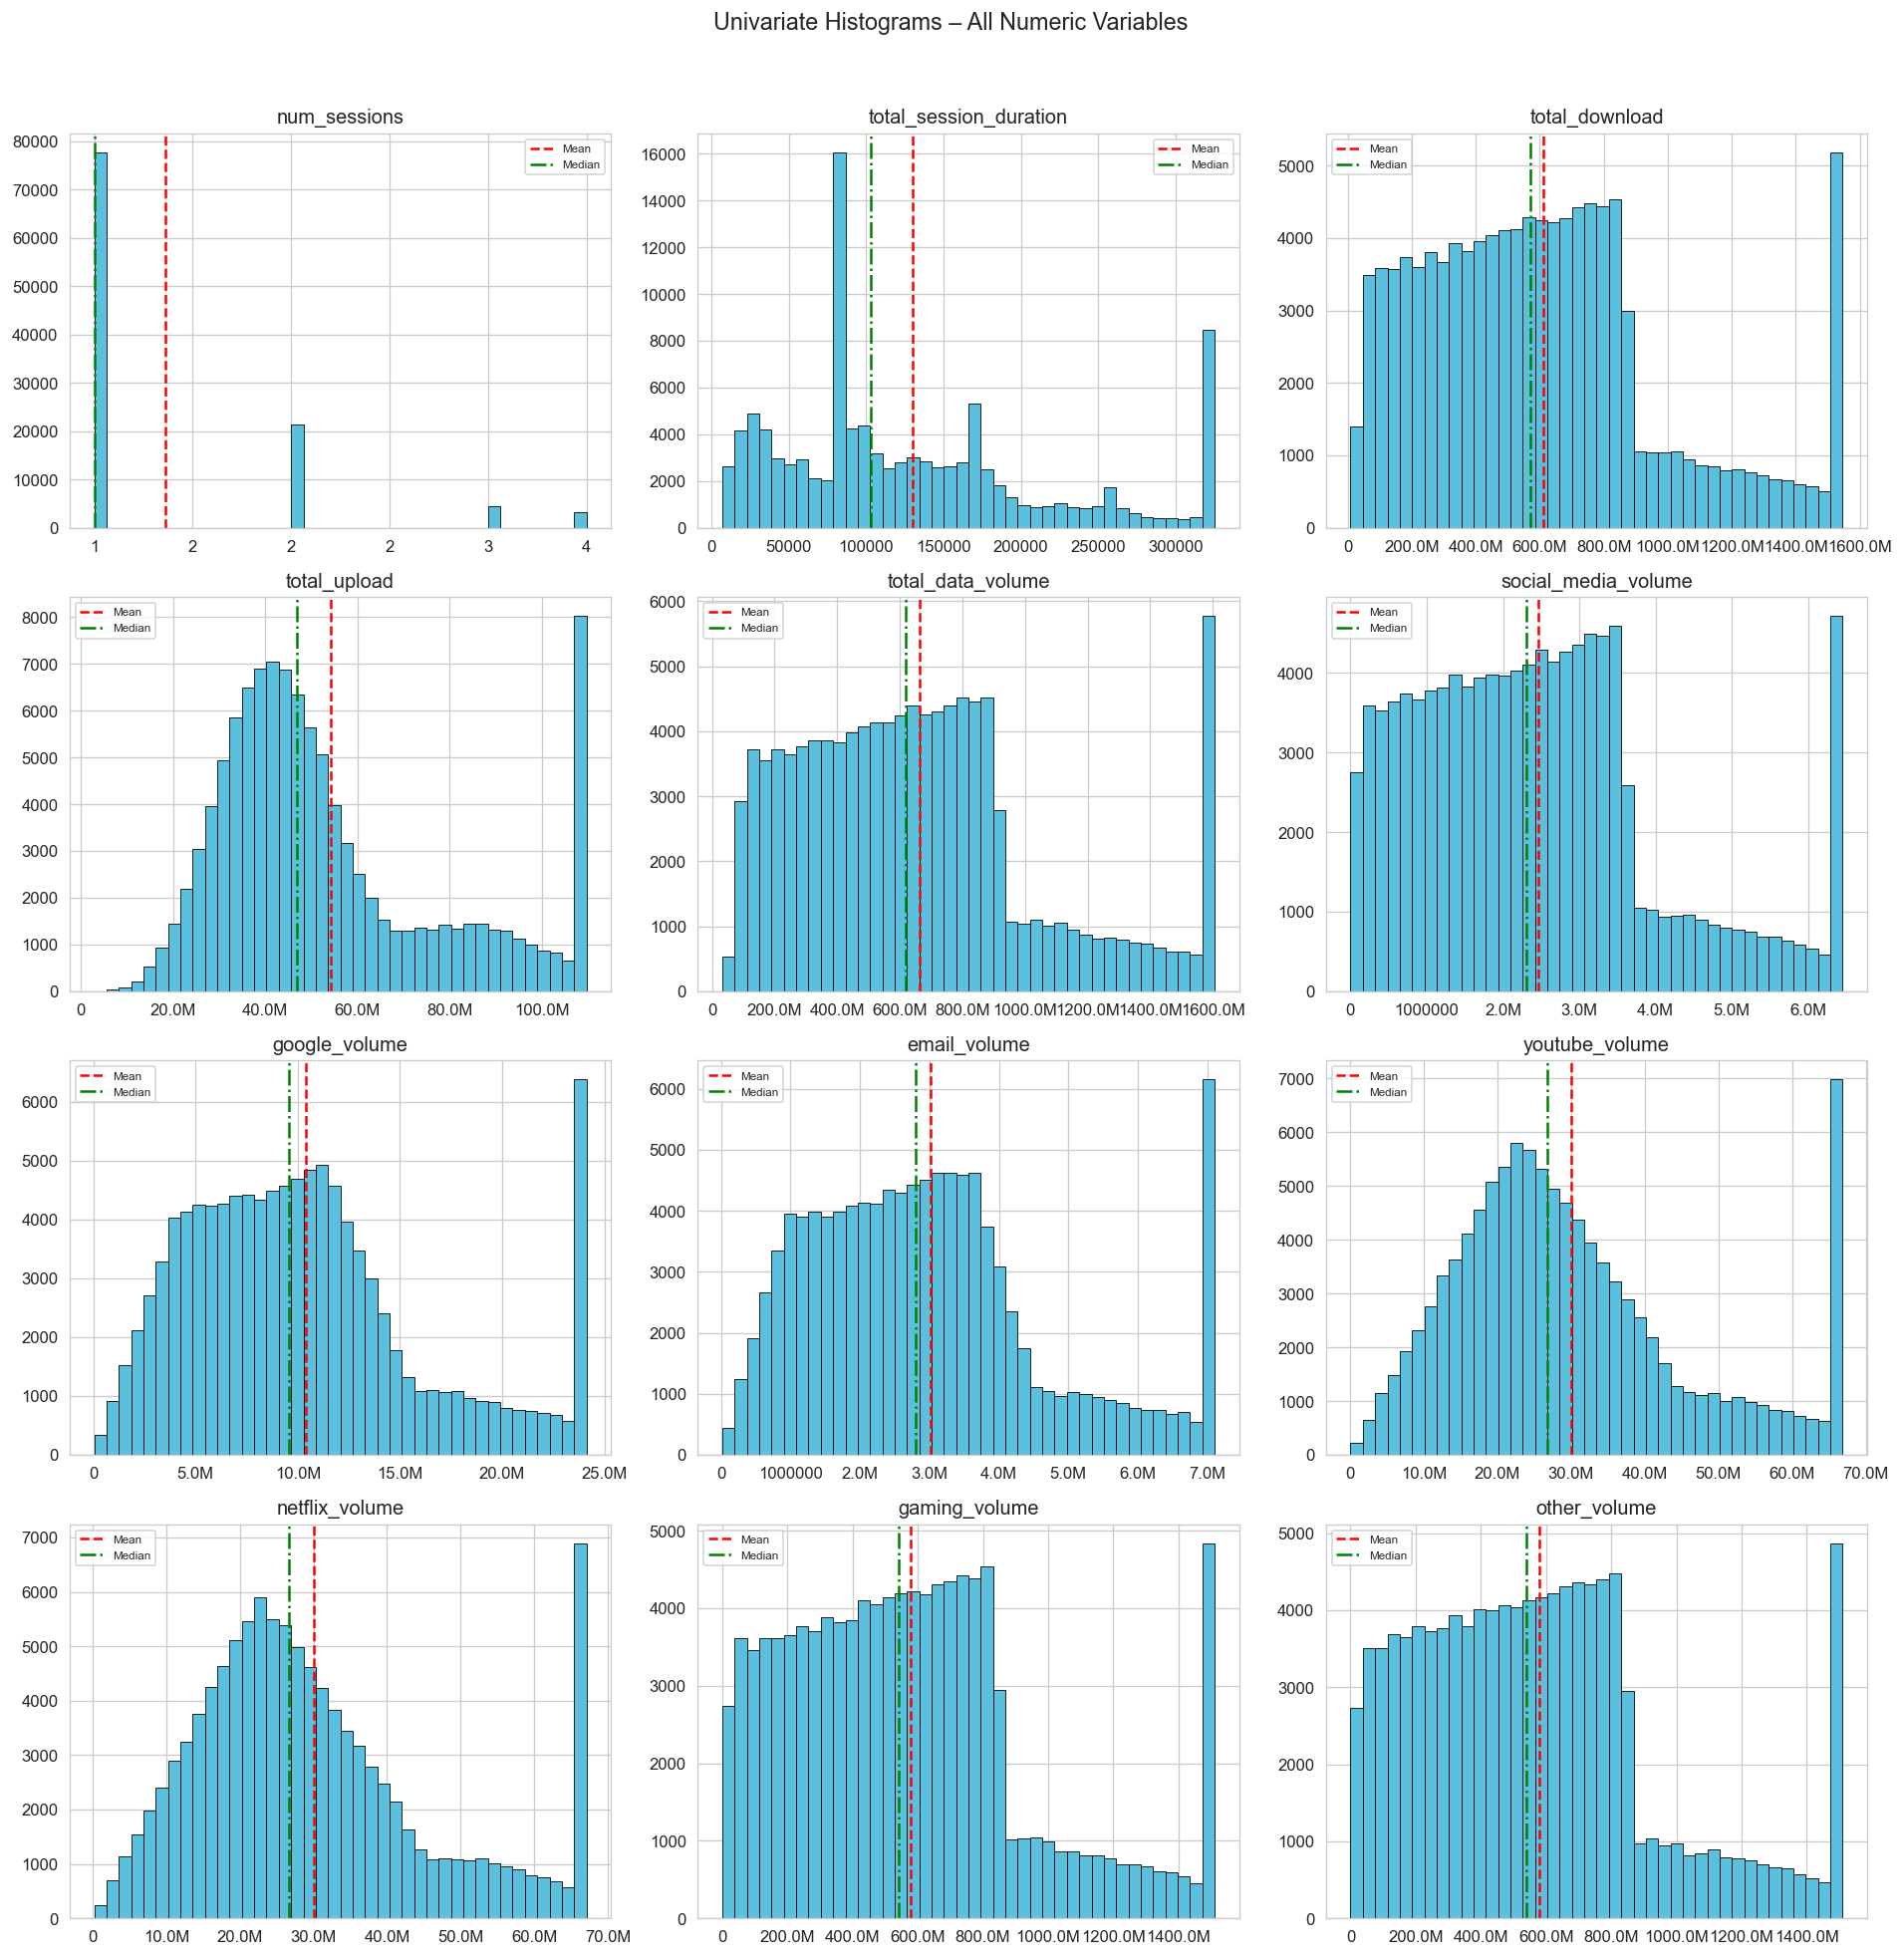

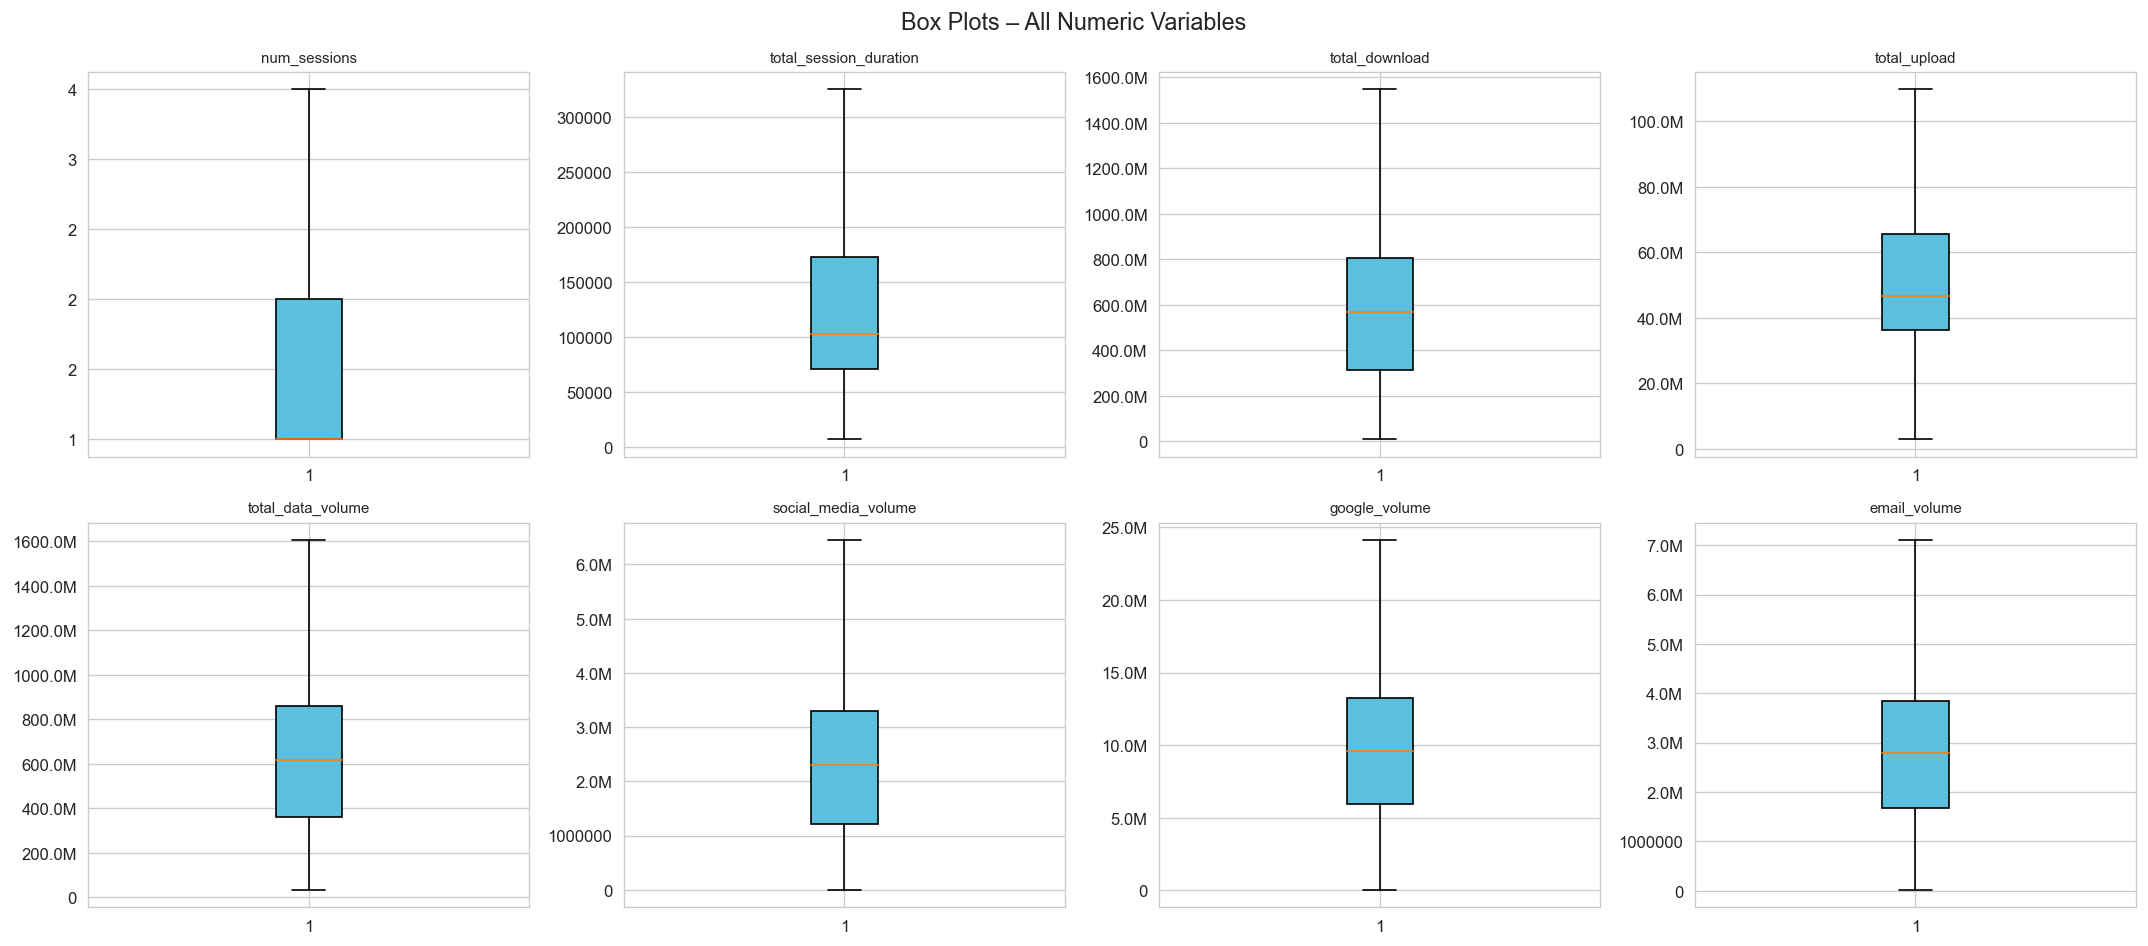


 BIVARIATE ANALYSIS  –  Each App vs Total Data (DL+UL)


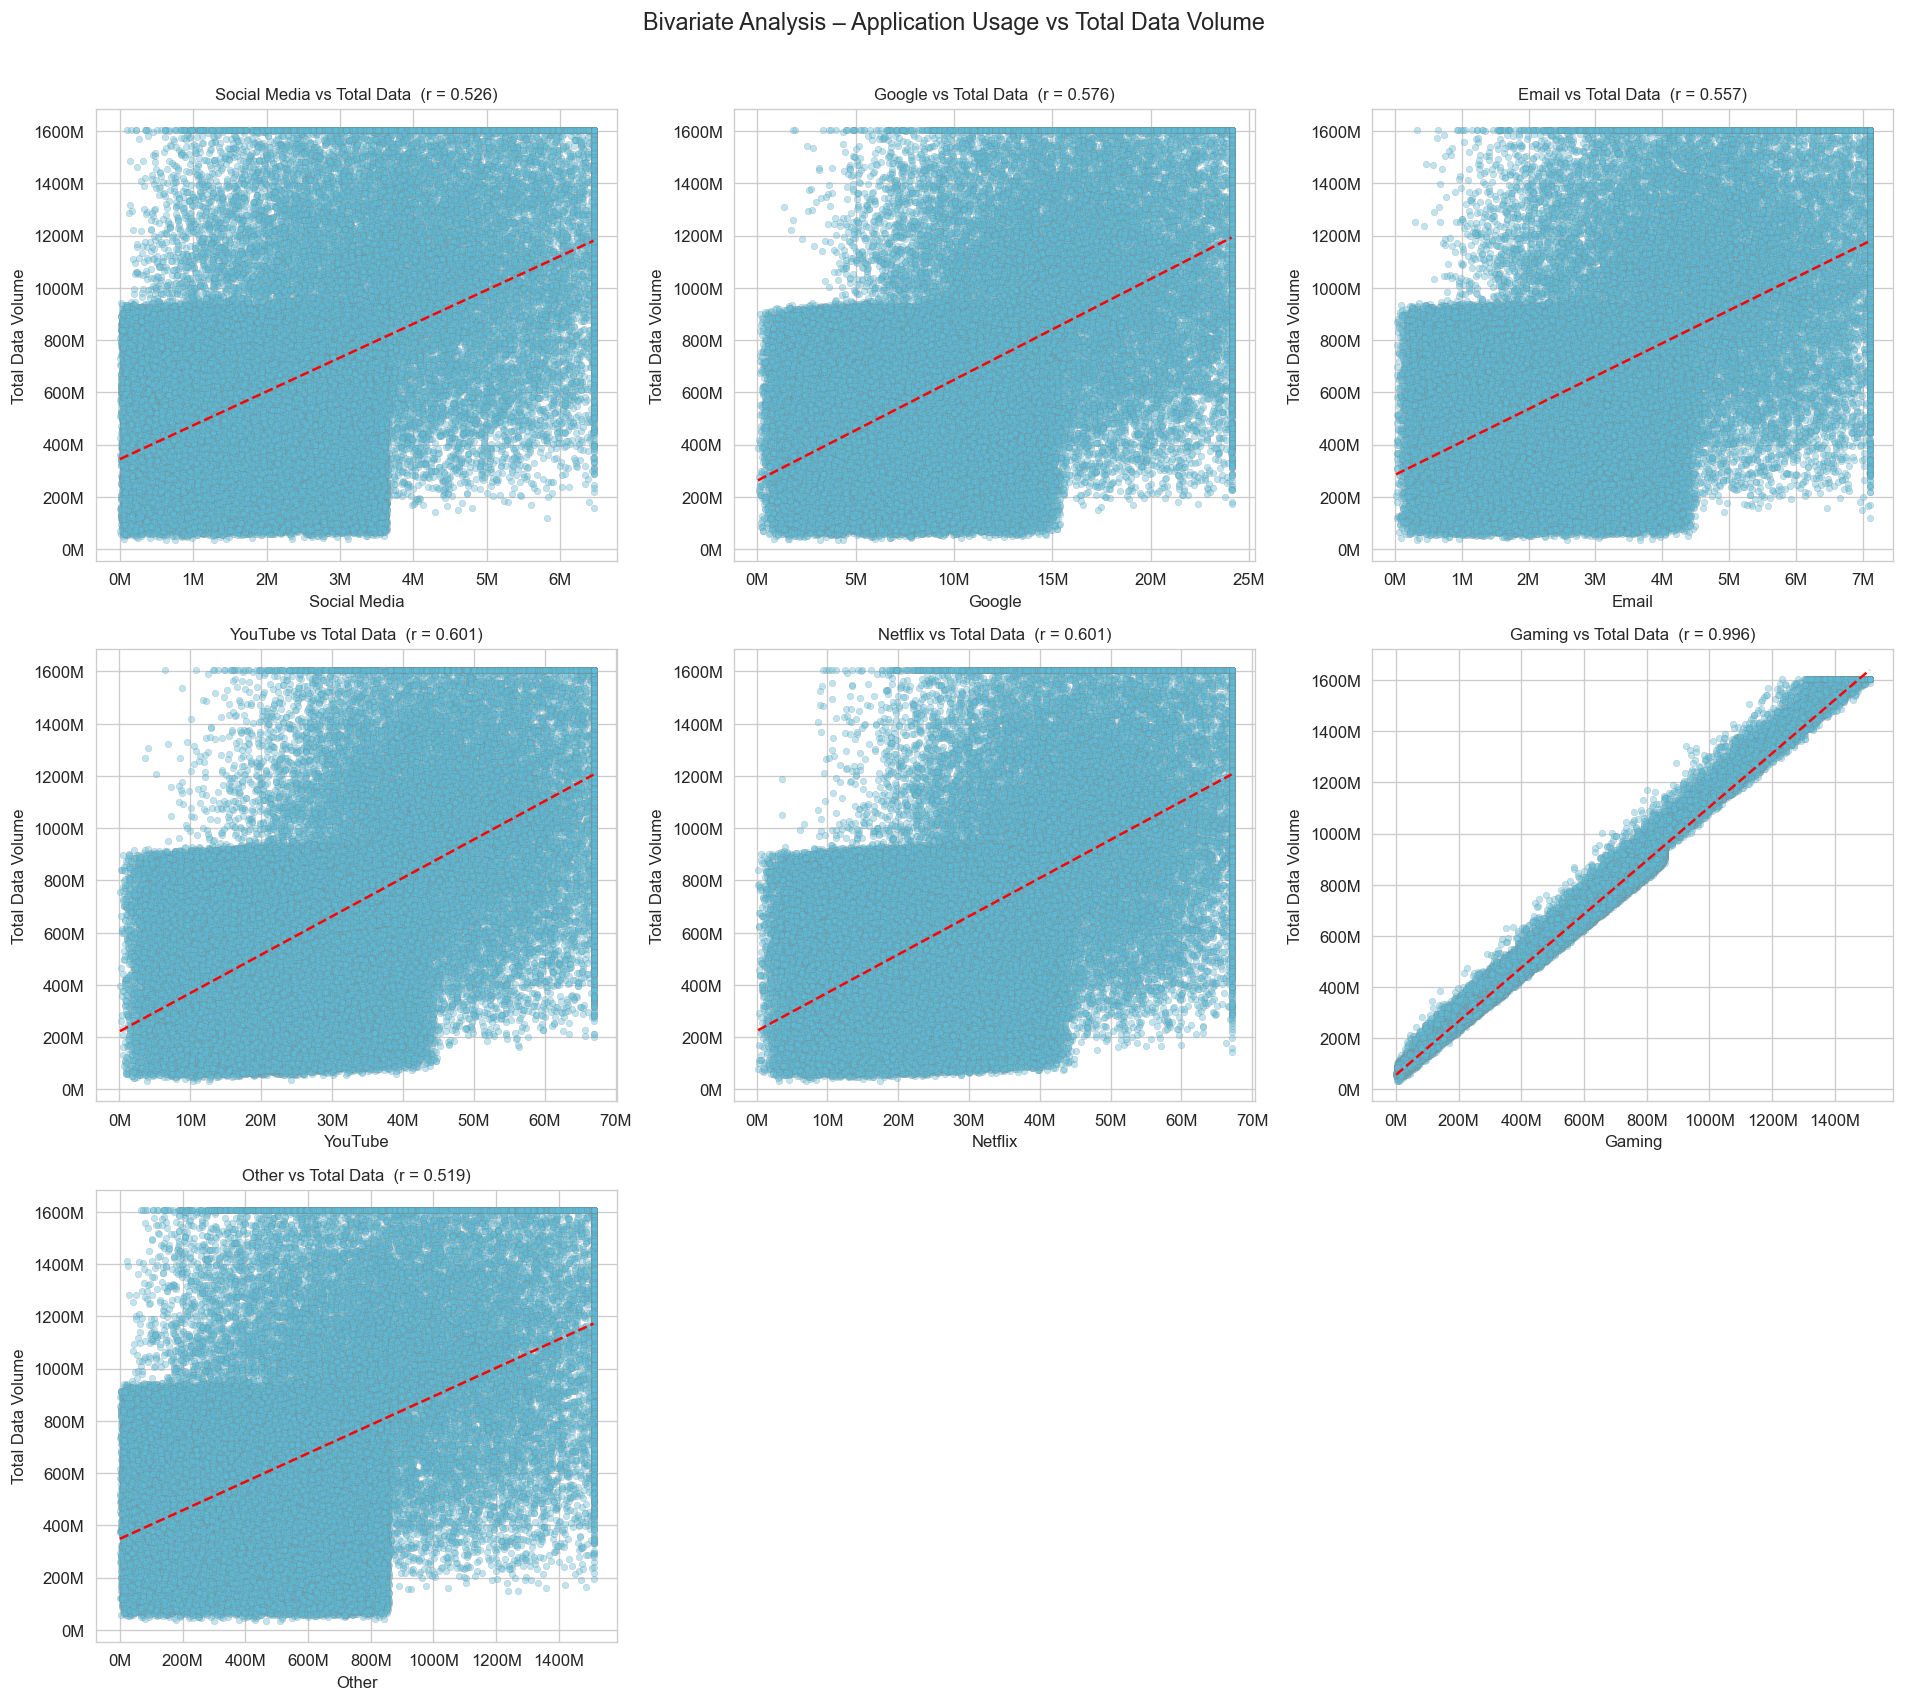


 CORRELATION MATRIX  –  App Data Volumes
                     social_media_volume  google_volume  email_volume  \
social_media_volume                1.000          0.540         0.533   
google_volume                      0.540          1.000         0.578   
email_volume                       0.533          0.578         1.000   
youtube_volume                     0.557          0.609         0.593   
netflix_volume                     0.559          0.609         0.596   
gaming_volume                      0.496          0.538         0.525   
other_volume                       0.498          0.539         0.529   

                     youtube_volume  netflix_volume  gaming_volume  \
social_media_volume           0.557           0.559          0.496   
google_volume                 0.609           0.609          0.538   
email_volume                  0.593           0.596          0.525   
youtube_volume                1.000           0.629          0.553   
netflix_volume         

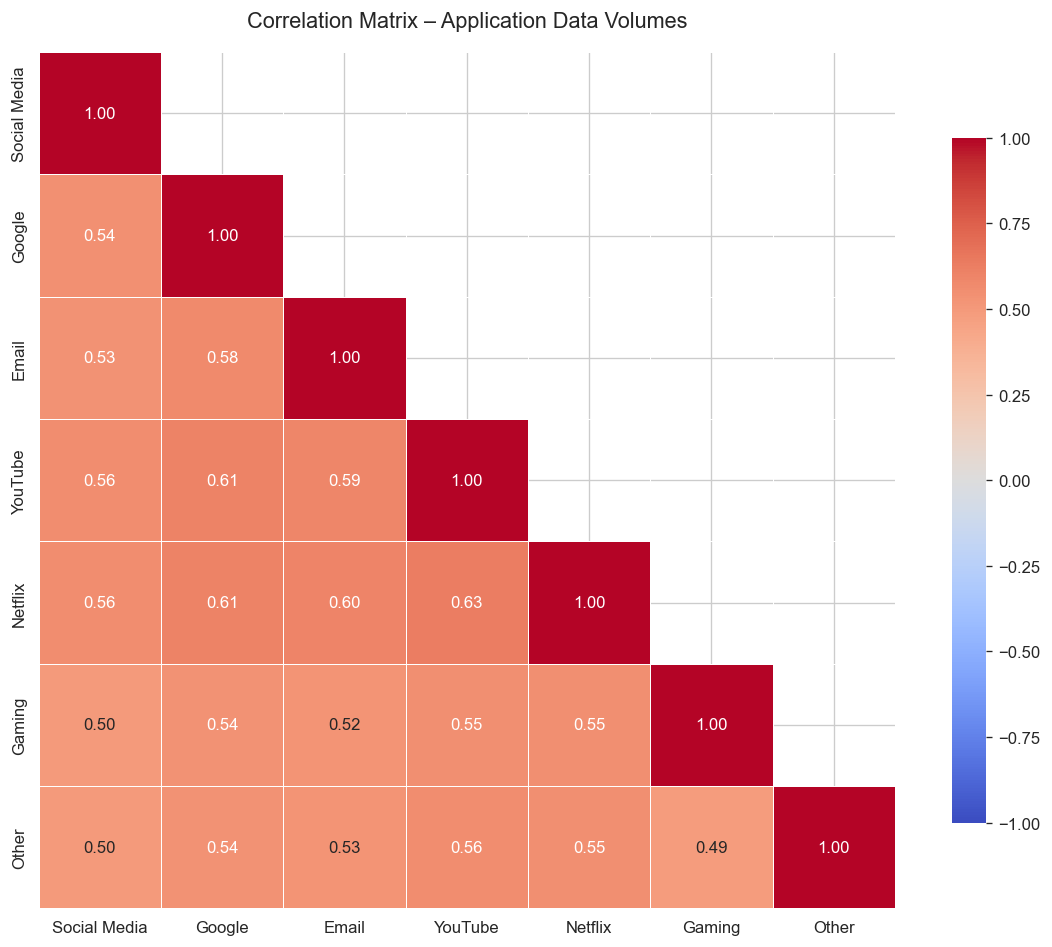


 PCA  –  Dimensionality Reduction

Explained Variance Ratio per PC:
  PC1: 0.6184  (cumulative: 0.6184)
  PC2: 0.0727  (cumulative: 0.6910)
  PC3: 0.0716  (cumulative: 0.7626)
  PC4: 0.0674  (cumulative: 0.8300)
  PC5: 0.0607  (cumulative: 0.8907)
  PC6: 0.0564  (cumulative: 0.9470)
  PC7: 0.0530  (cumulative: 1.0000)


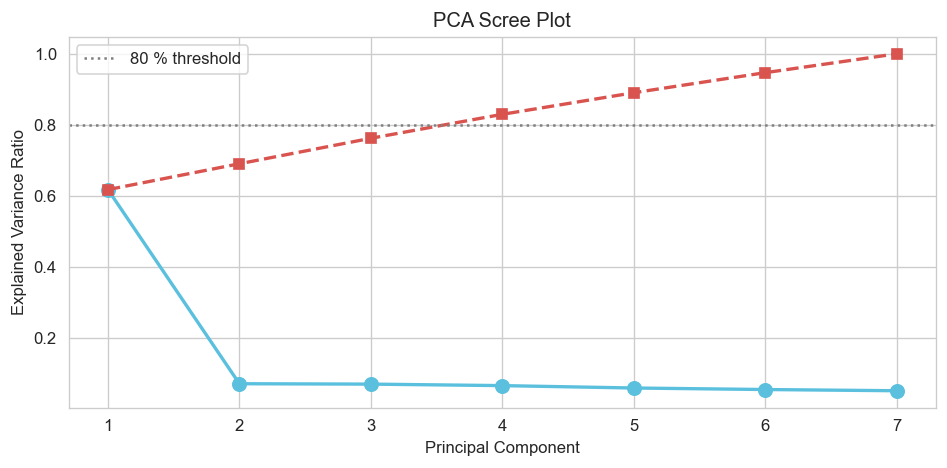

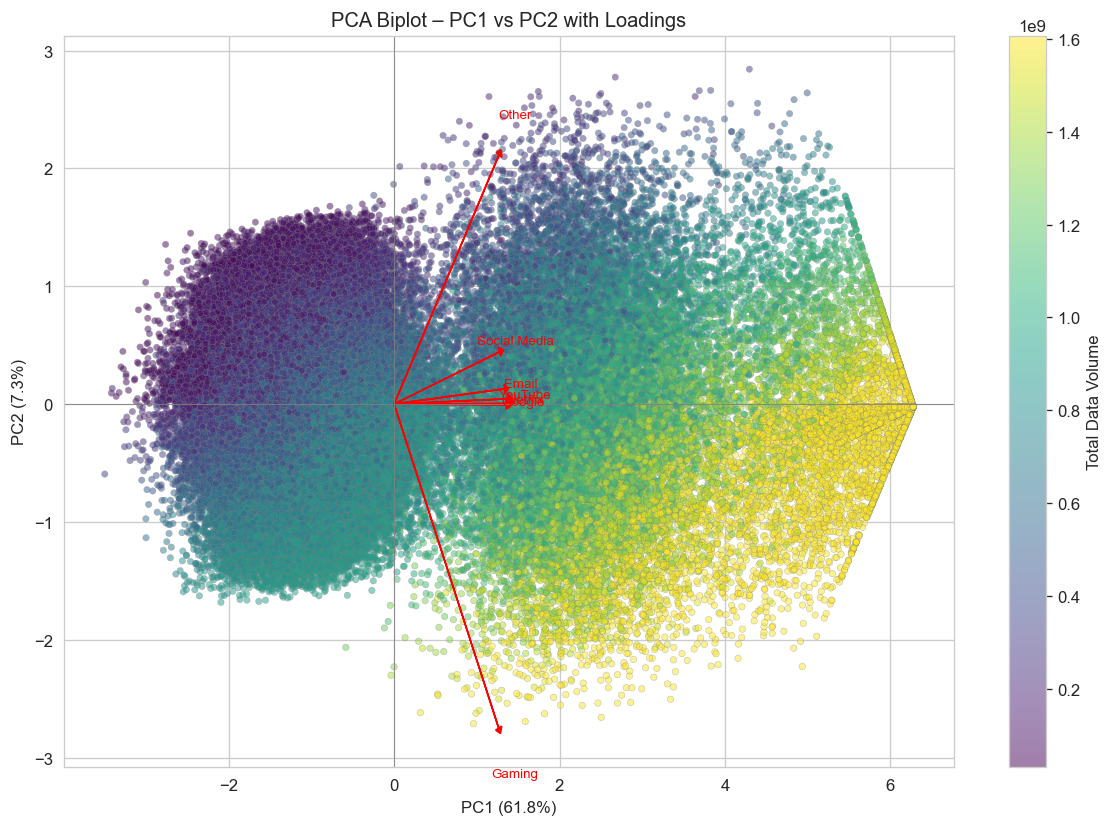


PCA Loadings:
                PC1    PC2    PC3    PC4    PC5    PC6    PC7
Social Media  0.364  0.126  0.768 -0.503  0.052  0.073  0.010
Google        0.387 -0.001  0.004  0.325 -0.555  0.661 -0.001
Email         0.381  0.037  0.048  0.467  0.771  0.195  0.027
YouTube       0.394  0.013  0.003  0.211 -0.217 -0.515  0.698
Netflix       0.395  0.001  0.030  0.226 -0.183 -0.497 -0.715
Gaming        0.361 -0.786 -0.304 -0.383  0.096  0.058 -0.001
Other         0.362  0.604 -0.560 -0.426  0.070  0.061 -0.018

 ANALYSIS COMPLETE  –  All plots saved.


In [ ]:
# ============================================================
# 3.  VARIABLE DESCRIPTION & DATA TYPES  (slide-ready print)
# ============================================================
print("\n" + "="*60)
print(" VARIABLE DESCRIPTIONS & DATA TYPES")
print("="*60)
desc_df = pd.DataFrame({
    'Column': user_behavior.columns,
    'Dtype': user_behavior.dtypes.values,
    'Non-Null': user_behavior.notna().sum().values,
    'Example': user_behavior.iloc[0].values
})
print(desc_df.to_string(index=False))

# ============================================================
# 4.  DECILE SEGMENTATION  (top-5 deciles highlighted)
# ============================================================
print("\n" + "="*60)
print(" DECILE SEGMENTATION  –  based on total_session_duration")
print("="*60)

user_behavior['decile'] = pd.qcut(
    user_behavior['total_session_duration'], q=10, labels=False, duplicates='drop'
) + 1   # 1-based labels

decile_summary = (
    user_behavior.groupby('decile').agg(
        num_users=('MSISDN/Number', 'count'),
        avg_duration=('total_session_duration', 'mean'),
        total_data=('total_data_volume', 'sum')
    ).reset_index()
)
print(decile_summary)

# Plot: Total Data per Decile
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d9534f' if d >= 6 else '#5bc0de' for d in decile_summary['decile']]
bars = ax.bar(decile_summary['decile'].astype(str), decile_summary['total_data'], color=colors)
ax.set_xlabel('Decile Class')
ax.set_ylabel('Total Data Volume (Bytes)')
ax.set_title('Total Data (DL+UL) per Duration Decile\n(Red = Top 5 Deciles)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))
plt.tight_layout()
plt.savefig('decile_segmentation.png')
plt.show()

# ============================================================
# 5.  BASIC METRICS  –  Descriptive Statistics
# ============================================================
print("\n" + "="*60)
print(" BASIC METRICS  –  Descriptive Statistics")
print("="*60)
print(user_behavior[NUMERIC_COLS].describe().T)

# ============================================================
# 6.  NON-GRAPHICAL UNIVARIATE ANALYSIS  –  Dispersion
# ============================================================
print("\n" + "="*60)
print(" NON-GRAPHICAL UNIVARIATE ANALYSIS  –  Dispersion Parameters")
print("="*60)

dispersion = pd.DataFrame({
    'Mean':    user_behavior[NUMERIC_COLS].mean(),
    'Median':  user_behavior[NUMERIC_COLS].median(),
    'Std Dev': user_behavior[NUMERIC_COLS].std(),
    'Var':     user_behavior[NUMERIC_COLS].var(),
    'IQR':     user_behavior[NUMERIC_COLS].quantile(0.75) - user_behavior[NUMERIC_COLS].quantile(0.25),
    'Skewness': user_behavior[NUMERIC_COLS].skew(),
    'Kurtosis': user_behavior[NUMERIC_COLS].kurtosis(),
    'CV (%)':  (user_behavior[NUMERIC_COLS].std() / user_behavior[NUMERIC_COLS].mean() * 100)
})
print(dispersion.round(2))

# ============================================================
# 7.  GRAPHICAL UNIVARIATE ANALYSIS
# ============================================================
print("\n" + "="*60)
print(" GRAPHICAL UNIVARIATE ANALYSIS")
print("="*60)

# 7a. Histograms for all numeric columns
n_cols = 3
n_rows = int(np.ceil(len(NUMERIC_COLS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    axes[i].hist(user_behavior[col], bins=40, color='#5bc0de', edgecolor='black', linewidth=0.5)
    axes[i].axvline(user_behavior[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(user_behavior[col].median(), color='green', linestyle='-.', label='Median')
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x > 1e6 else f'{x:.0f}'))

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Histograms – All Numeric Variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('univariate_histograms.png', bbox_inches='tight')
plt.show()

# 7b. Box plots for app volumes
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

plot_cols = NUMERIC_COLS  # all numeric
for i, col in enumerate(plot_cols):
    if i < len(axes):
        axes[i].boxplot(user_behavior[col].dropna(), vert=True,
                        patch_artist=True,
                        boxprops=dict(facecolor='#5bc0de'))
        axes[i].set_title(col, fontsize=9)
        axes[i].yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x > 1e6 else f'{x:.0f}'))

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots – All Numeric Variables', fontsize=14)
plt.tight_layout()
plt.savefig('univariate_boxplots.png', bbox_inches='tight')
plt.show()

# ============================================================
# 8.  BIVARIATE ANALYSIS  –  App volume vs Total Data
# ============================================================
print("\n" + "="*60)
print(" BIVARIATE ANALYSIS  –  Each App vs Total Data (DL+UL)")
print("="*60)

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

app_labels = ['Social Media', 'Google', 'Email', 'YouTube', 'Netflix', 'Gaming', 'Other']

for i, (col, label) in enumerate(zip(APP_COLS, app_labels)):
    axes[i].scatter(user_behavior[col], user_behavior['total_data_volume'],
                    alpha=0.4, s=15, color='#5bc0de', edgecolors='grey', linewidth=0.3)
    # Regression line
    z = np.polyfit(user_behavior[col], user_behavior['total_data_volume'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(user_behavior[col].min(), user_behavior[col].max(), 200)
    axes[i].plot(x_line, p(x_line), "r--", linewidth=1.5)
    corr = user_behavior[col].corr(user_behavior['total_data_volume'])
    axes[i].set_title(f'{label} vs Total Data  (r = {corr:.3f})', fontsize=10)
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Total Data Volume')
    axes[i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Hide unused subplot
axes[len(APP_COLS)].set_visible(False)
axes[len(APP_COLS)+1].set_visible(False)

plt.suptitle('Bivariate Analysis – Application Usage vs Total Data Volume', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('bivariate_app_vs_total.png', bbox_inches='tight')
plt.show()

# ============================================================
# 9.  CORRELATION ANALYSIS
# ============================================================
print("\n" + "="*60)
print(" CORRELATION MATRIX  –  App Data Volumes")
print("="*60)

corr_matrix = user_behavior[APP_COLS].corr()
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # upper triangle only
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            xticklabels=app_labels, yticklabels=app_labels, ax=ax,
            square=True, cbar_kws={"shrink": 0.8})
ax.set_title('Correlation Matrix – Application Data Volumes', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('correlation_matrix.png', bbox_inches='tight')
plt.show()

# ============================================================
# 10.  DIMENSIONALITY REDUCTION  –  PCA
# ============================================================
print("\n" + "="*60)
print(" PCA  –  Dimensionality Reduction")
print("="*60)

scaler = StandardScaler()
scaled = scaler.fit_transform(user_behavior[APP_COLS])

pca = PCA()
pca_transformed = pca.fit_transform(scaled)

# Explained variance
print("\nExplained Variance Ratio per PC:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.4f}  (cumulative: {pca.explained_variance_ratio_[:i+1].sum():.4f})")

# Plot 1: Scree plot
fig, ax = plt.subplots(figsize=(8, 4))
pcs = range(1, len(pca.explained_variance_ratio_)+1)
ax.plot(pcs, pca.explained_variance_ratio_, 'o-', color='#5bc0de', linewidth=2, markersize=8)
ax.plot(pcs, np.cumsum(pca.explained_variance_ratio_), 's--', color='#d9534f', linewidth=2, markersize=6)
ax.axhline(0.8, color='grey', linestyle=':', label='80 % threshold')
ax.set_xticks(pcs)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Scree Plot')
ax.legend()
plt.tight_layout()
plt.savefig('pca_scree.png')
plt.show()

# Plot 2: Biplot (PC1 vs PC2) coloured by total data
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(pca_transformed[:, 0], pca_transformed[:, 1],
                c=user_behavior['total_data_volume'], cmap='viridis',
                alpha=0.5, s=15, edgecolors='grey', linewidth=0.3)
plt.colorbar(sc, ax=ax, label='Total Data Volume')

# Loadings arrows
scale = 3.5
for i, label in enumerate(app_labels):
    ax.arrow(0, 0,
             pca.components_[0, i]*scale,
             pca.components_[1, i]*scale,
             head_width=0.08, head_length=0.05, fc='red', ec='red')
    ax.text(pca.components_[0, i]*scale*1.15,
            pca.components_[1, i]*scale*1.15, label, fontsize=8, ha='center', color='red')

ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA Biplot – PC1 vs PC2 with Loadings')
plt.tight_layout()
plt.savefig('pca_biplot.png')
plt.show()

# Loadings table
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(APP_COLS))], index=app_labels)
print("\nPCA Loadings:")
print(loadings.round(3))

print("\n" + "="*60)
print(" ANALYSIS COMPLETE  –  All plots saved.")
print("="*60)